# L1.3 — The performance envelope

**Level 1 · Core · 30 minutes**

**Goal.** You can describe an airframe as data.

**Check at the end.** You can say why a fixed-wing turn rate comes from the bank angle and the
speed, while a multirotor turn rate is one constant.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. An airframe is a value, not a class

`Performance` holds the horizontal limits of one airframe. It is plain frozen data. A new airframe
is a new **instance**, not a new subclass and not an edit to a step function.

This is the reason the limits are kept apart from the kinematics:

- The **kinematics** is *how* an aircraft moves. It is code.
- The **performance** is *how much* it can move. It is data that the code reads.

Two airframes with the same physics and different limits then share one integrator. Lesson L7.3
builds a new airframe with this alone.

In [1]:
import dataclasses

from opencdarr import M600, SMALL_FIXEDWING, Performance

print(f"{'field':<16}{'M600':>10}{'SMALL_FIXEDWING':>18}   differs")
for f in dataclasses.fields(Performance):
    a, b = getattr(M600, f.name), getattr(SMALL_FIXEDWING, f.name)
    print(f"{f.name:<16}{a:>10.1f}{b:>18.1f}   {'<--' if a != b else ''}")

field                 M600   SMALL_FIXEDWING   differs
v_max                 18.0              25.0   <--
v_min                -18.0              12.0   <--
ax                     5.0               2.0   <--
yaw_rate_max          90.0               0.0   <--
phi_max                0.0              44.0   <--
roll_rate_max          0.0              60.0   <--


## 2. The six fields, and which model reads which

| Field | Unit | Read by | What it limits |
| --- | --- | --- | --- |
| `v_max` | m/s | both | The maximum ground speed. |
| `v_min` | m/s | both | The minimum ground speed. For a fixed-wing this is the **stall** speed and must be positive. The M600 allows a negative value, because it can fly backward. |
| `ax` | m/s² | both | How fast the speed may change. A speed command becomes a ramp, not a jump. |
| `yaw_rate_max` | deg/s | `Multirotor` | How fast the nose may turn, apart from the direction of travel. |
| `phi_max` | deg | `FixedWing` | The maximum bank. This is the turn authority. |
| `roll_rate_max` | deg/s | `FixedWing` | How fast the bank may change. This makes `bank` part of the state. |

A multirotor leaves `phi_max` and `roll_rate_max` at 0. A fixed-wing leaves `yaw_rate_max` at 0.
A field at 0 is how an airframe says "I do not have this degree of freedom".

## 3. Two different turn laws

This is the difference that matters most in an encounter.

**A multirotor turns at a constant rate.** `yaw_rate_max` is degrees for each second, and the speed
does not change it.

**A fixed-wing turns by banking.** In a coordinated turn the rate and the radius are

$$\dot\psi = \frac{g \tan\phi}{V}, \qquad R = \frac{V^2}{g \tan\phi}$$

so the bank cap is a **speed-dependent** turn limit. Fly faster and the same bank gives a wider
circle. The turn is limited further inside a turn by the stall, because the load factor is
$n = 1/\cos\phi$.

Calculate both from the envelope, with no simulation.

at 44° of bank:
   12.0 m/s   radius   15.2 m   rate  45.2 deg/s
   17.0 m/s   radius   30.5 m   rate  31.9 deg/s
   25.0 m/s   radius   66.0 m   rate  21.7 deg/s


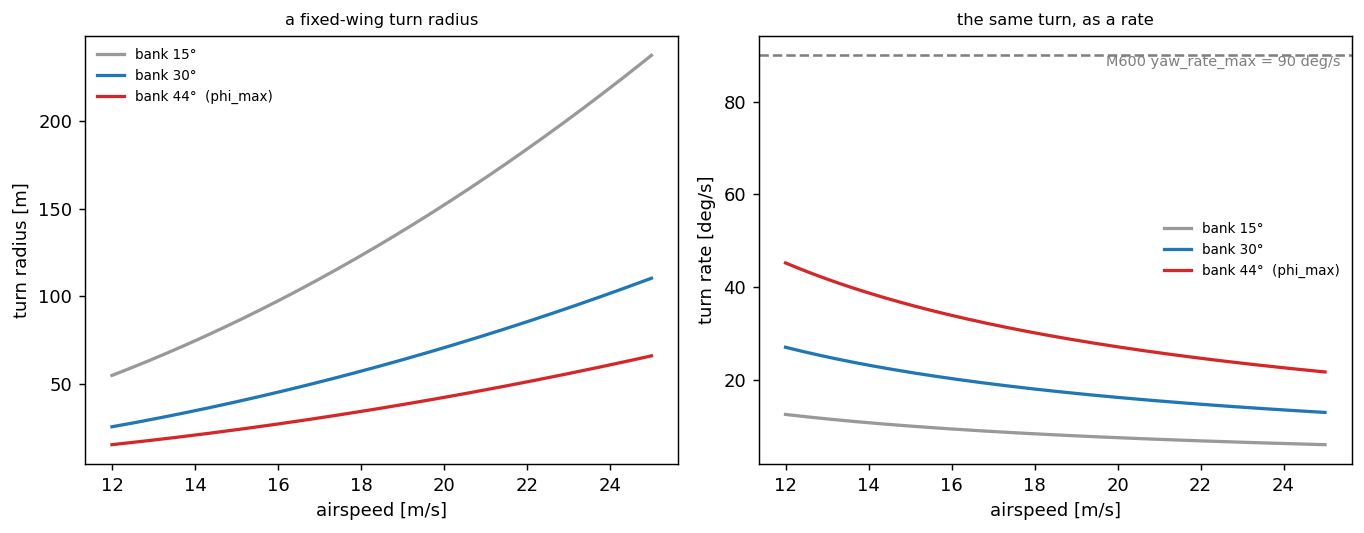

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY = "#1f77b4", "#d62728", "#7f7f7f"
G = 9.80665


def turn_radius(v: np.ndarray, phi_deg: float) -> np.ndarray:
    """The coordinated-turn radius [m] at airspeed v [m/s] and bank phi [deg]."""
    return v ** 2 / (G * np.tan(np.radians(phi_deg)))


def turn_rate(v: np.ndarray, phi_deg: float) -> np.ndarray:
    """The coordinated-turn rate [deg/s] at airspeed v [m/s] and bank phi [deg]."""
    return np.degrees(G * np.tan(np.radians(phi_deg)) / v)


v = np.linspace(SMALL_FIXEDWING.v_min, SMALL_FIXEDWING.v_max, 200)

fig, (ax_r, ax_w) = plt.subplots(1, 2, figsize=(10.6, 4.2))

for phi, colour in ((15.0, "0.6"), (30.0, BLUE), (SMALL_FIXEDWING.phi_max, RED)):
    label = f"bank {phi:.0f}°" + ("  (phi_max)" if phi == SMALL_FIXEDWING.phi_max else "")
    ax_r.plot(v, turn_radius(v, phi), lw=1.8, color=colour, label=label)
    ax_w.plot(v, turn_rate(v, phi), lw=1.8, color=colour, label=label)

ax_w.axhline(M600.yaw_rate_max, ls="--", lw=1.4, color=GREY)
ax_w.annotate(f"M600 yaw_rate_max = {M600.yaw_rate_max:.0f} deg/s", (0.98, M600.yaw_rate_max),
              xycoords=("axes fraction", "data"), ha="right", va="top", fontsize=8, color=GREY)

ax_r.set_ylabel("turn radius [m]")
ax_r.set_title("a fixed-wing turn radius", fontsize=9)
ax_w.set_ylabel("turn rate [deg/s]")
ax_w.set_title("the same turn, as a rate", fontsize=9)
for ax in (ax_r, ax_w):
    ax.set_xlabel("airspeed [m/s]")
    ax.legend(frameon=False, fontsize=7.5)
fig.tight_layout()

print(f"at {SMALL_FIXEDWING.phi_max:.0f}° of bank:")
for speed in (12.0, 17.0, 25.0):
    r = turn_radius(np.array([speed]), SMALL_FIXEDWING.phi_max)[0]
    w = turn_rate(np.array([speed]), SMALL_FIXEDWING.phi_max)[0]
    print(f"  {speed:>5.1f} m/s   radius {r:6.1f} m   rate {w:5.1f} deg/s")

## 4. How long a bank takes to reach

`roll_rate_max` is the reason `bank` is a field of `AircraftState` and not a number the model works
out each step. A fixed-wing cannot be at full bank at once. It rolls into the turn, and that delay
is real in an avoidance manoeuvre.

In [3]:
for perf, name in ((SMALL_FIXEDWING, "SMALL_FIXEDWING"),):
    t_roll = perf.phi_max / perf.roll_rate_max
    print(f"{name}: {perf.phi_max:.0f}° of bank at {perf.roll_rate_max:.0f} deg/s "
          f"takes {t_roll:.2f} s")
    print(f"  at 17 m/s it covers {17.0 * t_roll:.0f} m before the turn is fully established")

print(f"\nM600: no bank at all (phi_max = {M600.phi_max:.0f}), so the nose turns at "
      f"{M600.yaw_rate_max:.0f} deg/s with no roll-in")

SMALL_FIXEDWING: 44° of bank at 60 deg/s takes 0.73 s
  at 17 m/s it covers 12 m before the turn is fully established

M600: no bank at all (phi_max = 0), so the nose turns at 90 deg/s with no roll-in


## 5. Write your own airframe

Make a new `Performance`. Nothing else changes. Keep the rule of section 2: a multirotor leaves the
bank fields at 0, and a fixed-wing leaves `yaw_rate_max` at 0 and gives a positive `v_min`.

In [4]:
RACING_QUAD = Performance(v_max=30.0, v_min=-30.0, ax=12.0, yaw_rate_max=200.0)
HEAVY_LIFT = Performance(v_max=12.0, v_min=-6.0, ax=2.0, yaw_rate_max=45.0)
LARGE_FIXEDWING = Performance(v_max=60.0, v_min=28.0, ax=1.5, phi_max=30.0, roll_rate_max=25.0)

print(f"{'airframe':<18}{'v_max':>8}{'v_min':>8}{'ax':>7}{'yaw':>7}{'phi':>7}{'roll':>7}")
for name, p in (("M600", M600), ("RACING_QUAD", RACING_QUAD), ("HEAVY_LIFT", HEAVY_LIFT),
                ("SMALL_FIXEDWING", SMALL_FIXEDWING), ("LARGE_FIXEDWING", LARGE_FIXEDWING)):
    print(f"{name:<18}{p.v_max:>8.1f}{p.v_min:>8.1f}{p.ax:>7.1f}{p.yaw_rate_max:>7.0f}"
          f"{p.phi_max:>7.0f}{p.roll_rate_max:>7.0f}")

print(f"\nLARGE_FIXEDWING at its cruise of 40 m/s, at {LARGE_FIXEDWING.phi_max:.0f}° of bank:")
print(f"  turn radius {turn_radius(np.array([40.0]), LARGE_FIXEDWING.phi_max)[0]:.0f} m")

airframe             v_max   v_min     ax    yaw    phi   roll
M600                  18.0   -18.0    5.0     90      0      0
RACING_QUAD           30.0   -30.0   12.0    200      0      0
HEAVY_LIFT            12.0    -6.0    2.0     45      0      0
SMALL_FIXEDWING       25.0    12.0    2.0      0     44     60
LARGE_FIXEDWING       60.0    28.0    1.5      0     30     25

LARGE_FIXEDWING at its cruise of 40 m/s, at 30° of bank:
  turn radius 283 m


## 6. Let the pairing check refuse a mismatch

An envelope and an integrator must agree. A fixed-wing given a multirotor envelope has
`phi_max = 0`, so it can never bank, so it can never turn — and it would fly straight forever
without a word.

`Kinematics.validate_performance(perf)` is the check. It runs where you write the pair, not deep
inside the first step. `Agent` and `Airframe` call it for you.

In [5]:
import textwrap

from opencdarr.kinematics import FixedWing, Multirotor

trials = [
    ("Multirotor + M600", Multirotor(), M600),
    ("FixedWing + SMALL_FIXEDWING", FixedWing(), SMALL_FIXEDWING),
    ("Multirotor + SMALL_FIXEDWING", Multirotor(), SMALL_FIXEDWING),
    ("FixedWing + M600", FixedWing(), M600),
    ("FixedWing + RACING_QUAD", FixedWing(), RACING_QUAD),
]

for label, kinematics, perf in trials:
    try:
        kinematics.validate_performance(perf)
        print(f"{label:<32} accepted")
    except ValueError as exc:
        print(f"{label:<32} refused")
        print(textwrap.fill(str(exc), width=76, initial_indent=" " * 6,
                            subsequent_indent=" " * 6))

Multirotor + M600                accepted
FixedWing + SMALL_FIXEDWING      accepted
Multirotor + SMALL_FIXEDWING     refused
      Multirotor was given an envelope built for a banking airframe
      (phi_max=44.0, roll_rate_max=60.0); a multirotor does not bank. This
      looks like a fixed-wing envelope (e.g. SMALL_FIXEDWING); pass a
      multirotor Performance such as M600.
FixedWing + M600                 refused
      FixedWing was given an envelope it cannot fly: phi_max must be > 0 (a
      fixed-wing turns by banking); roll_rate_max must be > 0 (bank could
      never change); v_min is the stall speed and must be > 0. This looks
      like a multirotor envelope (e.g. M600); pass a fixed-wing Performance
      such as SMALL_FIXEDWING.
FixedWing + RACING_QUAD          refused
      FixedWing was given an envelope it cannot fly: phi_max must be > 0 (a
      fixed-wing turns by banking); roll_rate_max must be > 0 (bank could
      never change); v_min is the stall speed and must b

## Do it yourself

1. Make a `Performance` for a fixed-wing that cruises at 30 m/s and must turn inside a 200 m radius.
   Work out the bank that it needs from the radius law of section 3.
2. Give `RACING_QUAD` to `FixedWing().validate_performance`. Read the three reasons.
3. Halve `roll_rate_max` on `SMALL_FIXEDWING` with `dataclasses.replace`. Work out the new roll-in
   distance at 17 m/s.

## Check

1. Why does a fixed-wing turn rate come from `phi_max` and the speed, while a multirotor rate is
   one constant?
2. What does a field at 0 mean?
3. What would happen if the pairing check did not exist and you flew `FixedWing` with `M600`?

## Next

`L1.4 — The motion command`. You have the limits. Next you write the command that every module
speaks.